Import Libraries

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

Define GGITS Baseline Route

In [6]:
# Start (GGITS) to End (South Avenue Mall)
start_lat, start_lon = 23.1360, 79.8820 
end_lat, end_lon = 23.1400, 79.9500 
num_points = 100 # Total GPS pings

# 1. Baseline Route: Expected Trajectory
lats = np.linspace(start_lat, end_lat, num_points)
lons = np.linspace(start_lon, end_lon, num_points)
timestamps = [datetime.now() + timedelta(seconds=i*10) for i in range(num_points)]
status = ["Normal"] * num_points

Inject Transit Anomalies

In [7]:
# 2. Inject Anomaly: Unexplained Prolonged Stop 
# Gaadi row 30 par lagatar 2 minute ke liye ruk jayegi
stop_idx = 30
for i in range(1, 13): 
    lats[stop_idx + i] = lats[stop_idx]
    lons[stop_idx + i] = lons[stop_idx]
    status[stop_idx + i] = "Prolonged Stop"

# 3. Inject Anomaly: Significant Trajectory Deviation
# Gaadi row 70 par achanak expected path se bhatak jayegi
dev_idx = 70
for i in range(10):
    lats[dev_idx + i] += 0.005 
    lons[dev_idx + i] -= 0.005
    status[dev_idx + i] = "Deviation"

Save & Preview Data

In [8]:
# 4. Compile into DataFrame and Save
df = pd.DataFrame({
    "Timestamp": timestamps, 
    "Latitude": lats, 
    "Longitude": lons, 
    "Status": status
})

df.to_csv("ggits_transit_data.csv", index=False)
print("✅ GGITS Synthetic Transit Data generated successfully!")

# Display the data directly in the notebook output
df.iloc[25:35] # This will show the transition from Normal to Prolonged Stop

✅ GGITS Synthetic Transit Data generated successfully!


,Timestamp,Latitude,Longitude,Status
25,2026-09-09 09:00:50.399768,23.137010,79.899172,Normal
26,2026-09-09 09:01:00.399768,23.137051,79.899859,Normal
27,2026-09-09 09:01:10.399768,23.137091,79.900545,Normal
28,2026-09-09 09:01:20.399768,23.137131,79.901232,Normal
29,2026-09-09 09:01:30.399768,23.137172,79.901919,Normal
30,2026-09-09 09:01:40.399768,23.137212,79.902606,Normal
31,2026-09-09 09:01:50.399768,23.137212,79.902606,Prolonged Stop
32,2026-09-09 09:02:00.399768,23.137212,79.902606,Prolonged Stop
33,2026-09-09 09:02:10.399768,23.137212,79.902606,Prolonged Stop
34,2026-09-09 09:02:20.399768,23.137212,79.902606,Prolonged Stop


Visualize the Transit Data

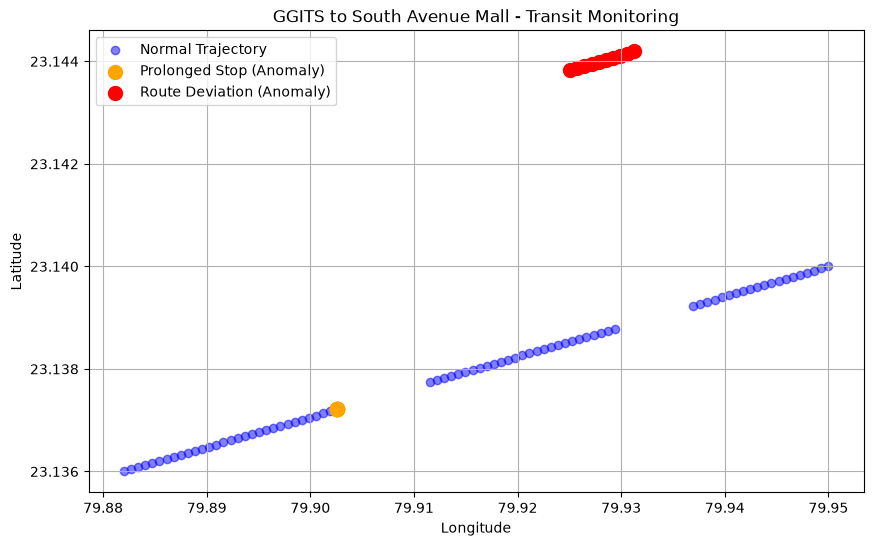

In [9]:
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("ggits_transit_data.csv")

# Create the plot
plt.figure(figsize=(10, 6))

# Plot normal route
normal = df[df['Status'] == 'Normal']
plt.scatter(normal['Longitude'], normal['Latitude'], c='blue', label='Normal Trajectory', alpha=0.5)

# Plot Prolonged Stop
stop = df[df['Status'] == 'Prolonged Stop']
plt.scatter(stop['Longitude'], stop['Latitude'], c='orange', label='Prolonged Stop (Anomaly)', s=100)

# Plot Deviation
dev = df[df['Status'] == 'Deviation']
plt.scatter(dev['Longitude'], dev['Latitude'], c='red', label='Route Deviation (Anomaly)', s=100)

plt.title("GGITS to South Avenue Mall - Transit Monitoring")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.show()

Train the Anomaly Detection Model (The Core Engine)

In [10]:
from sklearn.ensemble import IsolationForest

# Extracting Features  
# Hum Latitude aur Longitude ko as features pass karenge
X = df[['Latitude', 'Longitude']]

# Initializing Model (contamination = 0.22 kyunki humare paas 22 anomalous points hain 100 mein se..... 12 deviation, 10 prolonged stop)
model = IsolationForest(contamination=0.22, random_state=42)

# Model training & getting predictions...
df['Anomaly_Score'] = model.fit_predict(X)

# Anomaly_Score -1 ka matlab anomaly detected, 1 ka matlab normal
df['ML_Prediction'] = df['Anomaly_Score'].apply(lambda x: 'Alert Triggered' if x == -1 else 'Safe')

# Checking whether model ne anomalies sahi pakdi...
print(df[df['ML_Prediction'] == 'Alert Triggered'][['Timestamp', 'Latitude', 'Longitude', 'Status']])

   Timestamp   Latitude  Longitude     Status
0    56:40.4  23.136000  79.882000     Normal
1    56:50.4  23.136040  79.882687     Normal
2    57:00.4  23.136081  79.883374     Normal
3    57:10.4  23.136121  79.884061     Normal
4    57:20.4  23.136162  79.884747     Normal
5    57:30.4  23.136202  79.885434     Normal
6    57:40.4  23.136242  79.886121     Normal
43   03:50.4  23.137737  79.911535     Normal
70   08:20.4  23.143828  79.925081  Deviation
71   08:30.4  23.143869  79.925768  Deviation
72   08:40.4  23.143909  79.926455  Deviation
73   08:50.4  23.143949  79.927141  Deviation
74   09:00.4  23.143990  79.927828  Deviation
75   09:10.4  23.144030  79.928515  Deviation
76   09:20.4  23.144071  79.929202  Deviation
77   09:30.4  23.144111  79.929889  Deviation
78   09:40.4  23.144152  79.930576  Deviation
79   09:50.4  23.144192  79.931263  Deviation
80   10:00.4  23.139232  79.936949     Normal
97   12:50.4  23.139919  79.948626     Normal
98   13:00.4  23.139960  79.949313